In [9]:
import numpy as np
import pandas as pd
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# Define mean vector and covariance matrix
mean = [0, 0]    # 2D mean
cov = [[1, 0],
       [0, 1]]   # 2D identity covariance (no correlation)

# Create a multivariate normal distribution object
rv = multivariate_normal(mean=mean, cov=cov)

# Evaluate the PDF at a specific point
point = [0.5, -0.2]
pdf_value = rv.pdf(point)
print("PDF at point", point, "=", pdf_value)

PDF at point [0.5, -0.2] = 0.13767257383326081


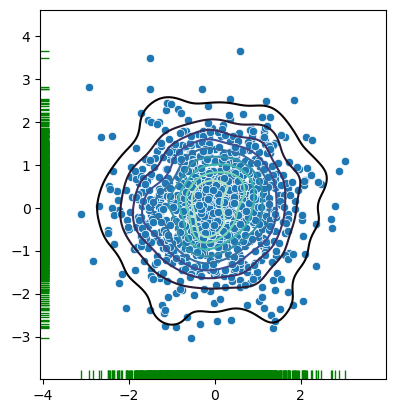

In [35]:
# Generate random samples
samples = rv.rvs(size=1000)
ax  = sns.kdeplot(x=samples[:,0],
            y=samples[:,1],
            thresh=0.05,
            levels=10,cmap='mako')
sns.scatterplot(x=samples[:,0],y=samples[:,1])
sns.rugplot(x=samples[:,0], y=samples[:,1] ,color="g")

ax.set_aspect('equal', 'box')

### In higher dimensional space

<Figure size 200x200 with 0 Axes>

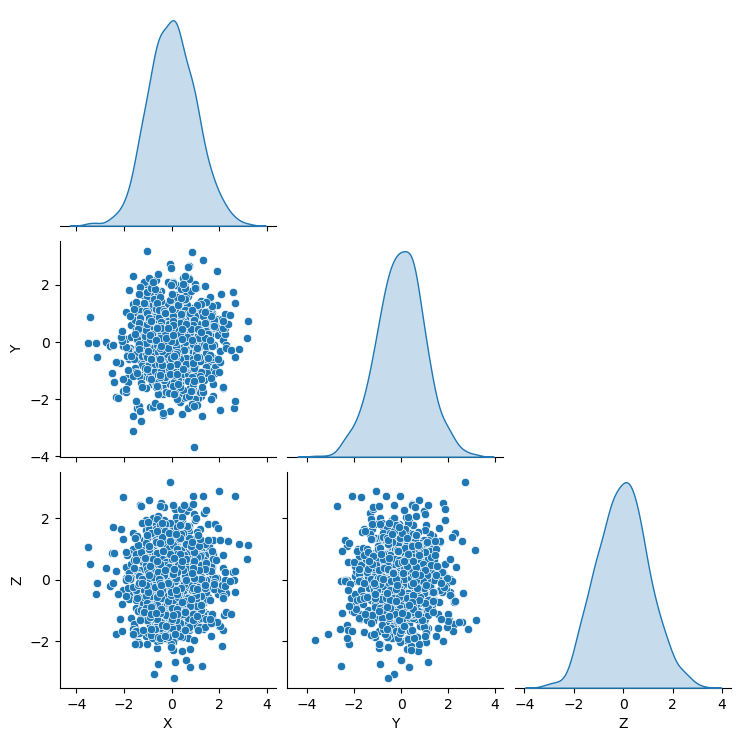

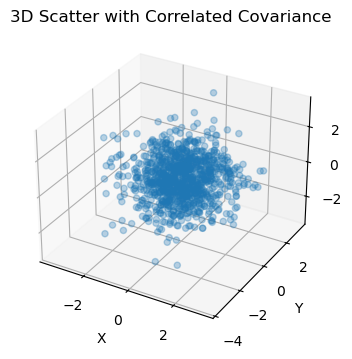

In [62]:
# Example: Introduce correlation between X and Y
mean = [0, 0, 0]
cov = np.eye(3)  # 3D identity covariance

rv = multivariate_normal(mean=mean, cov=cov)

# Generate samples
samples = rv.rvs(size=1000)

# Put in a DataFrame
df = pd.DataFrame(samples, columns=['X','Y','Z'])

# Pairplot
fig = plt.figure(figsize=(2,2))
sns.pairplot(df, corner=True, diag_kind="kde")
plt.show()

# 3D scatter
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['X'], df['Y'], df['Z'], alpha=0.3)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title("3D Scatter with Correlated Covariance")
plt.show()

<Figure size 200x200 with 0 Axes>

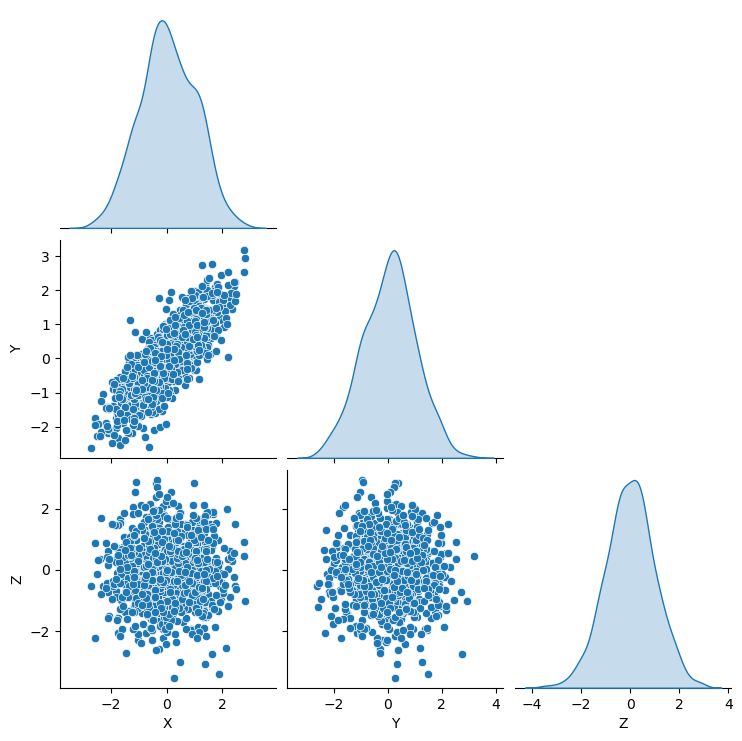

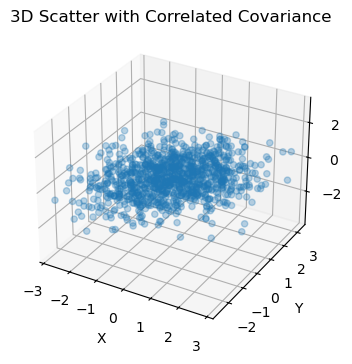

In [69]:
# Example: Introduce correlation between X and Y
mean = [0, 0, 0]
cov = [[  1,  0.8,  0],     # 0.8 correlation between X and Y
       [0.8,    1,  0],
       [  0,    0,  1]]

rv = multivariate_normal(mean=mean, cov=cov)

# Generate samples
samples = rv.rvs(size=1000)

# Put in a DataFrame
df = pd.DataFrame(samples, columns=['X','Y','Z'])

# Pairplot
fig = plt.figure(figsize=(2,2))
sns.pairplot(df, corner=True, diag_kind="kde")
plt.show()

# 3D scatter
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['X'], df['Y'], df['Z'], alpha=0.3)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title("3D Scatter with Correlated Covariance")
plt.show()

-----

0.9972999823465558

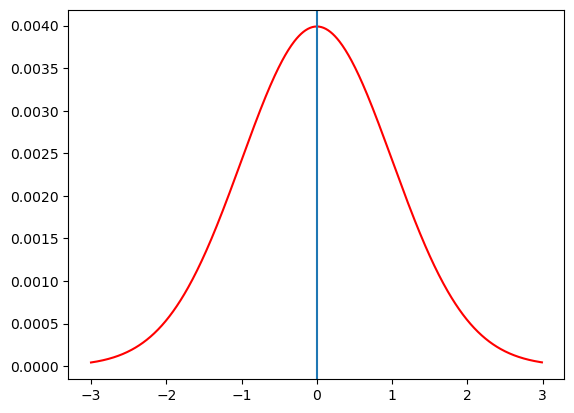

In [ ]:
step = 0.01 
xvals = np.arange(-3,3,step)
values = [step * multivariate_normal(mean=0, cov=1).pdf(i) for i in xvals]

ax = sns.lineplot(x=xvals,y=values,color='r')
ax.axvline( multivariate_normal(mean=0, cov=1).pdf(0) * step )

np.sum(values)